In [1]:
# ============================================================
# Functional space occupancy (weighted by OC) in PCA space
# - Uses unweighted traits (g1, sla_random, wd_random) as coordinates
# - Uses OC as weights (occupancy) to build weighted density / contours
# - Plots early vs late windows per scenario with baseline (regclim) in grey
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
base_path = (
    "/Users/biancarius/Desktop/"
    "CAETE-DVM-alloc-allom-including_alloc2_Cm2/"
    "paper_resilience/tables_results/"
)

table_2y = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_30prec_2y.csv"
)
table_2y["Source"] = "2y"

table_4y = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_30prec_4y.csv"
)
table_4y["Source"] = "4y"

table_6y = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_30prec_6y.csv"
)
table_6y["Source"] = "6y"

table_8y = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_30prec_8y.csv"
)
table_8y["Source"] = "8y"

table_regclim = pd.read_csv(
    f"{base_path}PLS_alive_traits_MAN_regularclimate.csv"
)
table_regclim["Source"] = "regclim"


In [6]:
df = pd.concat(
    [table_regclim, table_2y, table_4y, table_6y, table_8y],
    ignore_index=True
)

df["Source"] = pd.Categorical(
    df["Source"],
    categories=["regclim", "8y", "6y", "4y", "2y"],
    ordered=True
)

In [7]:
year_map = (
    df[["Source", "YEAR"]]
    .drop_duplicates()
    .sort_values(["Source", "YEAR"])
    .assign(
        run_year=lambda x: x.groupby("Source").cumcount()
    )
    .reset_index(drop=True)
)


/var/folders/0p/11283pfj6n55yg7pf77flbpc0000gp/T/ipykernel_32144/2116828136.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  run_year=lambda x: x.groupby("Source").cumcount()


In [8]:
# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

# Expected columns in your dataframe:
# YEAR, Source, OC, g1, sla_random, wd_random
trait_cols = ["g1", "sla_random", "wd_random"]
weight_col = "OC"
year_col = "YEAR"
source_col = "Source"

# Scenario order and colors (edit as needed)
scenario_order = ["regclim", "8y", "6y", "4y", "2y"]
scenario_colors = {
    "regclim": "#000000",  # not used as colored overlay; baseline is grey in all panels
    "8y": "#3B5BA9",
    "6y": "#2A9D8F",
    "4y": "#B58900",
    "2y": "#8C2D3E",
}

# Early window: first N years of each scenario
early_n_years = 5

# Late window: last N years of each scenario
late_n_years = 5

# Weighted histogram settings for contour estimation
bins = 120  # increase for smoother contours, decrease for faster plotting
contour_levels = [0.50, 0.95]  # mass levels (50% and 95%)

In [9]:




# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def add_pca_scores(df_in: pd.DataFrame, trait_cols: list) -> tuple[pd.DataFrame, PCA, StandardScaler]:
    """
    Fit PCA on standardized trait space (pooled across all scenarios and years),
    then add PC1/PC2 scores to the dataframe.
    """
    df = df_in.copy()

    # Drop rows with missing traits or weights
    df = df.dropna(subset=trait_cols + [weight_col, year_col, source_col])

    # Standardize traits so that g1 does not dominate due to scale differences
    scaler = StandardScaler()
    X = scaler.fit_transform(df[trait_cols].values)

    # Fit PCA (2D for visualization)
    pca = PCA(n_components=2, random_state=0)
    PCs = pca.fit_transform(X)

    df["PC1"] = PCs[:, 0]
    df["PC2"] = PCs[:, 1]

    return df, pca, scaler


def get_early_late_masks(df: pd.DataFrame, early_n: int, late_n: int) -> tuple[pd.Series, pd.Series]:
    """
    Create boolean masks for early and late windows within each scenario.
    Early = first N years; Late = last N years (based on YEAR).
    """
    # Rank years within each scenario (ascending)
    df_sorted = df.sort_values([source_col, year_col]).copy()

    # Early years mask
    df_sorted["rank_year"] = df_sorted.groupby(source_col)[year_col].rank(method="dense", ascending=True)
    early_mask = df_sorted["rank_year"] <= early_n

    # Late years mask
    df_sorted["rank_year_desc"] = df_sorted.groupby(source_col)[year_col].rank(method="dense", ascending=False)
    late_mask = df_sorted["rank_year_desc"] <= late_n

    # Return masks aligned to original df_sorted index (we will use df_sorted downstream)
    return df_sorted, early_mask, late_mask


def weighted_centroid(x: np.ndarray, y: np.ndarray, w: np.ndarray) -> tuple[float, float]:
    """
    Compute weighted centroid in 2D.
    """
    w_sum = np.sum(w)
    if w_sum <= 0:
        return np.nan, np.nan
    return float(np.sum(w * x) / w_sum), float(np.sum(w * y) / w_sum)


def weighted_hist2d_density(x, y, w, xedges, yedges) -> np.ndarray:
    """
    Compute a 2D weighted histogram density normalized to sum to 1.
    """
    H, _, _ = np.histogram2d(x, y, bins=[xedges, yedges], weights=w)
    total = H.sum()
    if total > 0:
        H = H / total
    return H


def density_threshold_for_mass(H: np.ndarray, mass_level: float) -> float:
    """
    Given a normalized 2D density H (sum=1), return the density threshold t such that
    the region where H >= t contains 'mass_level' of total probability mass.
    """
    flat = H.ravel()
    idx = np.argsort(flat)[::-1]  # descending
    sorted_vals = flat[idx]
    cum_mass = np.cumsum(sorted_vals)
    # Find the smallest density value that achieves the desired mass
    k = np.searchsorted(cum_mass, mass_level, side="left")
    k = np.clip(k, 0, len(sorted_vals) - 1)
    return sorted_vals[k]


def plot_weighted_contours(ax, H, xcenters, ycenters, levels_mass, color, linewidth=1.6, alpha=1.0, linestyle="-"):
    """
    Plot contour lines for given mass levels (e.g., 0.5 and 0.95) from density grid H.
    """
    # Convert mass levels into density thresholds
    thresholds = [density_threshold_for_mass(H, m) for m in levels_mass]
    # Note: contour expects increasing levels; thresholds are decreasing with mass
    # so we sort them for plotting.
    thresholds_sorted = np.sort(thresholds)

    Xc, Yc = np.meshgrid(xcenters, ycenters, indexing="ij")
    ax.contour(
        Xc, Yc, H,
        levels=thresholds_sorted,
        colors=[color] * len(thresholds_sorted),
        linewidths=linewidth,
        linestyles=linestyle,
        alpha=alpha
    )



/var/folders/0p/11283pfj6n55yg7pf77flbpc0000gp/T/ipykernel_32144/556516019.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sorted["rank_year"] = df_sorted.groupby(source_col)[year_col].rank(method="dense", ascending=True)
/var/folders/0p/11283pfj6n55yg7pf77flbpc0000gp/T/ipykernel_32144/556516019.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sorted["rank_year_desc"] = df_sorted.groupby(source_col)[year_col].rank(method="dense", ascending=False)


ValueError: Contour levels must be increasing

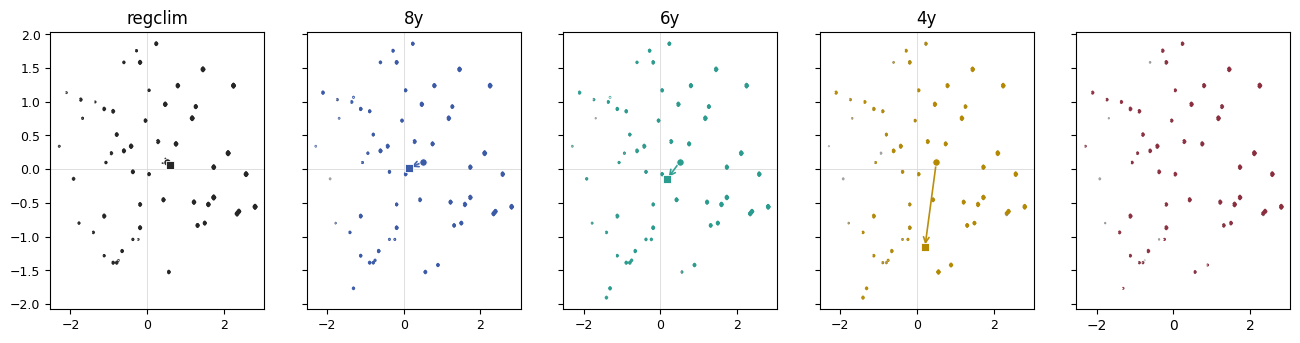

In [10]:


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

# df = ...  # <-- your dataframe goes here (already loaded)
# Example: df = pd.read_csv("your_file.csv")

# 1) Add PCA scores
df_pca, pca_model, scaler_model = add_pca_scores(df, trait_cols=trait_cols)

# 2) Build early/late masks per scenario
df_pca_sorted, early_mask, late_mask = get_early_late_masks(df_pca, early_n=early_n_years, late_n=late_n_years)

# 3) Define common plotting range for all panels
pc1 = df_pca_sorted["PC1"].values
pc2 = df_pca_sorted["PC2"].values
pad1 = 0.05 * (np.nanmax(pc1) - np.nanmin(pc1) + 1e-9)
pad2 = 0.05 * (np.nanmax(pc2) - np.nanmin(pc2) + 1e-9)

x_min, x_max = np.nanmin(pc1) - pad1, np.nanmax(pc1) + pad1
y_min, y_max = np.nanmin(pc2) - pad2, np.nanmax(pc2) + pad2

xedges = np.linspace(x_min, x_max, bins + 1)
yedges = np.linspace(y_min, y_max, bins + 1)

xcenters = 0.5 * (xedges[:-1] + xedges[1:])
ycenters = 0.5 * (yedges[:-1] + yedges[1:])

# 4) Precompute baseline (regclim) early and late densities for reference
base = df_pca_sorted[df_pca_sorted[source_col] == "regclim"].copy()

base_early = base[early_mask.loc[base.index]].copy()
base_late  = base[late_mask.loc[base.index]].copy()

H_base_early = weighted_hist2d_density(
    base_early["PC1"].values, base_early["PC2"].values,
    base_early[weight_col].values, xedges, yedges
)
H_base_late = weighted_hist2d_density(
    base_late["PC1"].values, base_late["PC2"].values,
    base_late[weight_col].values, xedges, yedges
)

# 5) Make figure: one panel per scenario (excluding regclim if you prefer)
ncols = len(scenario_order)
fig, axes = plt.subplots(1, ncols, figsize=(3.2 * ncols, 3.6), sharex=True, sharey=True)

if ncols == 1:
    axes = [axes]

for ax, scen in zip(axes, scenario_order):
    # Subset scenario data
    dsc = df_pca_sorted[df_pca_sorted[source_col] == scen].copy()

    dsc_early = dsc[early_mask.loc[dsc.index]].copy()
    dsc_late  = dsc[late_mask.loc[dsc.index]].copy()

    # Weighted densities
    H_early = weighted_hist2d_density(
        dsc_early["PC1"].values, dsc_early["PC2"].values,
        dsc_early[weight_col].values, xedges, yedges
    )
    H_late = weighted_hist2d_density(
        dsc_late["PC1"].values, dsc_late["PC2"].values,
        dsc_late[weight_col].values, xedges, yedges
    )

    # Plot baseline contours in grey (early as dashed, late as solid)
    plot_weighted_contours(
        ax, H_base_early, xcenters, ycenters,
        levels_mass=contour_levels, color="0.6", linewidth=1.2, alpha=0.9, linestyle="--"
    )
    plot_weighted_contours(
        ax, H_base_late, xcenters, ycenters,
        levels_mass=contour_levels, color="0.6", linewidth=1.2, alpha=0.9, linestyle="-"
    )

    # Plot scenario contours (early dashed, late solid)
    if scen != "regclim":
        col = scenario_colors.get(scen, "C0")
    else:
        # If plotting regclim panel, use black for its own contours
        col = "0.15"

    plot_weighted_contours(
        ax, H_early, xcenters, ycenters,
        levels_mass=contour_levels, color=col, linewidth=1.8, alpha=0.95, linestyle="--"
    )
    plot_weighted_contours(
        ax, H_late, xcenters, ycenters,
        levels_mass=contour_levels, color=col, linewidth=1.8, alpha=0.95, linestyle="-"
    )

    # Centroids (weighted) and arrow early -> late
    cx_e, cy_e = weighted_centroid(
        dsc_early["PC1"].values, dsc_early["PC2"].values, dsc_early[weight_col].values
    )
    cx_l, cy_l = weighted_centroid(
        dsc_late["PC1"].values, dsc_late["PC2"].values, dsc_late[weight_col].values
    )

    ax.scatter([cx_e], [cy_e], s=28, marker="o", color=col, edgecolor="white", linewidth=0.6, zorder=5)
    ax.scatter([cx_l], [cy_l], s=28, marker="s", color=col, edgecolor="white", linewidth=0.6, zorder=5)

    if np.isfinite(cx_e) and np.isfinite(cx_l):
        ax.annotate(
            "", xy=(cx_l, cy_l), xytext=(cx_e, cy_e),
            arrowprops=dict(arrowstyle="->", lw=1.2, color=col, alpha=0.95)
        )

    # Titles and styling
    ax.set_title(scen, fontsize=12)
    ax.axhline(0, lw=0.6, color="0.85", zorder=0)
    ax.axvline(0, lw=0.6, color="0.85", zorder=0)
    ax.tick_params(labelsize=9)

# Axis labels
axes[0].set_ylabel("PC2", fontsize=11)
for ax in axes:
    ax.set_xlabel("PC1", fontsize=11)

# Legend (manual, simple)
# Note: use the caption to explain dashed=early, solid=late; grey=baseline
fig.suptitle("Functional space occupancy (weighted by OC) in PCA trait space", fontsize=13, y=1.02)
fig.tight_layout()

plt.show()

# ------------------------------------------------------------
# OPTIONAL: print PCA loadings for interpretation (trait syndromes)
# ------------------------------------------------------------
loadings = pd.DataFrame(
    pca_model.components_.T,
    index=trait_cols,
    columns=["PC1_loading", "PC2_loading"]
)
expl = pca_model.explained_variance_ratio_
print("\nPCA explained variance ratio:", expl)
print("\nPCA loadings:\n", loadings)
